# 5.06 — SRR3997504 + SRR4099955 salmon / L1EM 5'RACE experiment

Port of legacy `4.09-ach-albert_exp_SRR3997504_SRR4099955` (cells 16/20) into the R/ggplot
reproducibility scheme. **Stage A** (`.trap/scripts/aggregate_srr_l1em_exp.py`, run on Grace)
joins five per-L1-locus quantifications on the locus id (`region`) and writes the tidy
`results/srr_experiment/l1em_salmon_fpm.csv`
(`region, chrom, chromStart, chromEnd, target, category, strand, race5, method, value`).
**Stage B** (this notebook) renders `SRR3997504_SRR4099955_salmon_l1em_exp` to
`reports/figures/srr_experiment/`.

Each panel regresses one method's per-locus estimate (`value`) against the 5'RACE
ground-truth percentage (`race5`): **(A) AlbertSalmon, (B) Salmon** (salmon TPM,
classifier-filtered vs plain) and **(C) AlbertEM, (D) L1EM** (EM rpm). Points are coloured by
target subfamily (L1HS / L1PA2); a red `lm` fit + R² label per panel; the largest-residual
locus is circled. Same data, panels, per-panel filter and statistics as the legacy PNG;
verify against `notebooks/images/SRR3997504_SRR4099955_salmon_l1em_exp.png`.


In [6]:
## Reproducibility & environment capture -------------------------------
set.seed(3469)
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(jsonlite)
})
options(repr.plot.width = 14, repr.plot.height = 12)
theme_set(theme_bw(base_size = 28.125))   # legacy 4.09 fonts (plt.rc size 18; bold titles/labels)


In [7]:
## Paths, provenance, palette ------------------------------------------
results_dir <- file.path("..", "results", "srr_experiment")
figures_dir <- file.path("..", "reports", "figures", "srr_experiment")
dir.create(figures_dir, recursive = TRUE, showWarnings = FALSE)
cat("results_dir:", results_dir, "\n"); cat("figures_dir:", figures_dir, "\n")

manifest_path <- file.path(results_dir, "manifest.json")
if (file.exists(manifest_path)) {
  manifest <- fromJSON(manifest_path)
  cat("git_commit:", manifest$git_commit, " timestamp:", manifest$timestamp_utc, "\n")
  if (!is.null(manifest$seed)) stopifnot(manifest$seed == 3469)
} else warning("manifest.json not found — run .trap/scripts/aggregate_srr_l1em_exp.py first.")

# Target subfamily palette (fixed; consistent with 5.03/5.04). Red #D62728 stays reserved for
# the lm fit line; green #2CA02C marks the largest-residual locus (legacy highlight).
target_palette <- c("L1HS" = "#1F77B4", "L1PA2" = "#FF7F0E")
target_shape   <- c("L1HS" = 16, "L1PA2" = 4)
panel_order    <- c("AlbertSalmon", "Salmon", "AlbertEM", "L1EM")

save_fig <- function(plot, stem, width = 13, height = 11) {
  for (ext in c("png", "pdf"))
    suppressMessages(ggsave(file.path(figures_dir, paste0(stem, ".", ext)),
                            plot, width = width, height = height, dpi = 300, bg = "white"))
  invisible(plot)
}


results_dir: ../results/srr_experiment 
figures_dir: ../reports/figures/srr_experiment 
git_commit: d2465ab6d07b598b48a626265a38e5ab59ebc315  timestamp: 2026-07-05T01:25:03.654978+00:00 


In [8]:
## Load the tidy table + validation checks ----------------------------
exp_path <- file.path(results_dir, "l1em_salmon_fpm.csv")
stopifnot("l1em_salmon_fpm.csv not found — run the Stage-A translator" = file.exists(exp_path))
E <- fread(exp_path)

req <- c("region", "target", "category", "race5", "method", "value")
stopifnot("missing required columns" = all(req %in% names(E)))
stopifnot("race5 must be finite and >= 0" = all(is.finite(E$race5) & E$race5 >= 0))
stopifnot("value (FPM/TPM) must be >= 0 where present" = all(E$value >= -1e-9 | is.na(E$value)))

# legacy cell-20 selection: expressed L1HS/L1PA2 loci (category > 0).
E <- E[grepl("^L1HS|^L1PA2", target) & category > 0]
E[, target := ifelse(grepl("^L1HS", target), "L1HS", "L1PA2")]
present <- intersect(panel_order, unique(E$method))
if (length(present) < length(panel_order))
  warning(sprintf("missing method(s): %s", paste(setdiff(panel_order, present), collapse = ", ")))
stopifnot("expected targets L1HS/L1PA2 present" = all(c("L1HS", "L1PA2") %in% E$target))
cat("Loaded", nrow(E), "method-locus rows;", uniqueN(E$region), "loci; methods:",
    paste(present, collapse = ", "), "\n")


Loaded 5932 method-locus rows; 1483 loci; methods: AlbertSalmon, Salmon, AlbertEM, L1EM 


         method    r2
         <fctr> <num>
1: AlbertSalmon 0.912
2:       Salmon 0.860
3:     AlbertEM 0.845
4:         L1EM 0.831


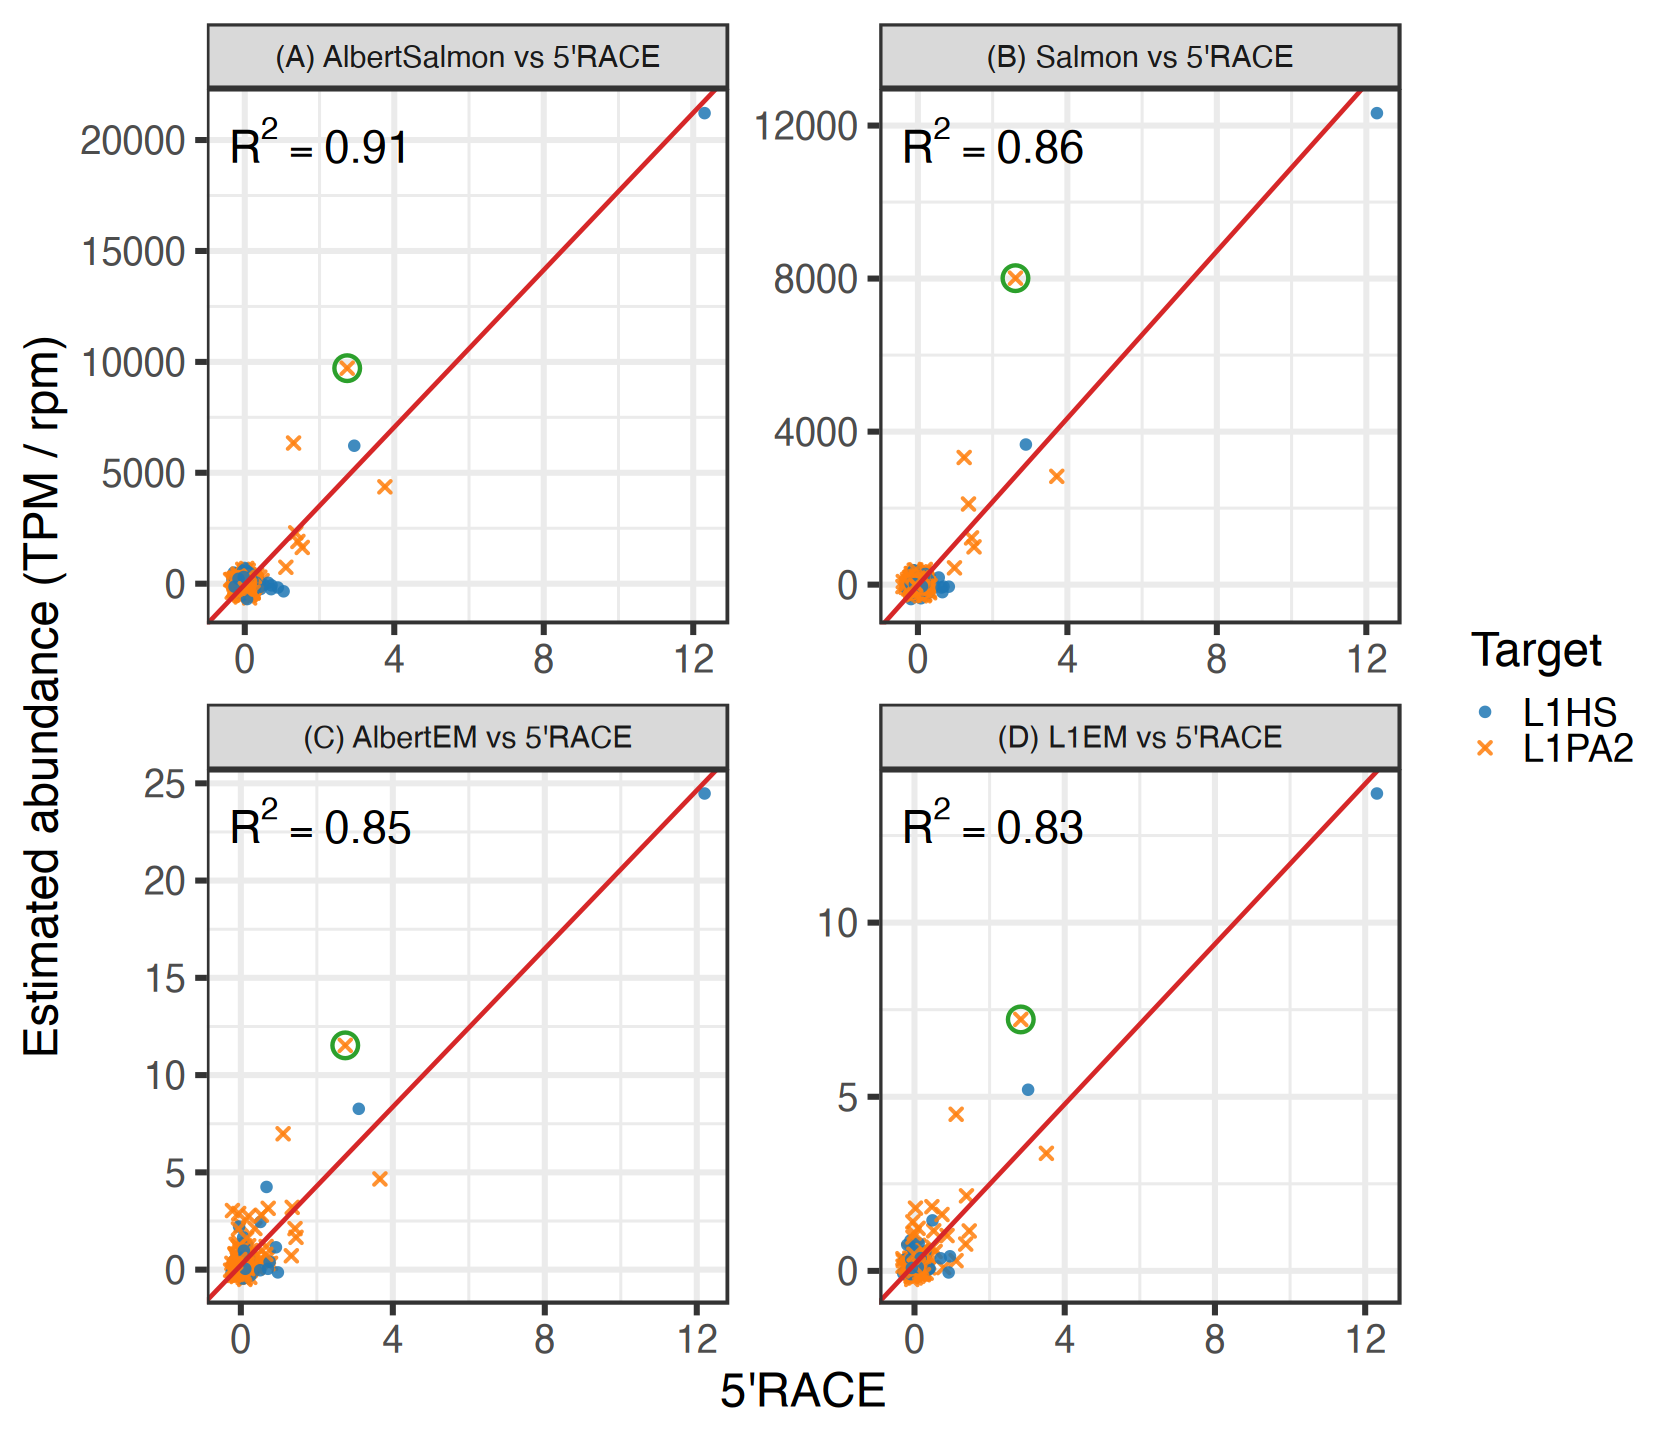

In [9]:
## Figure: SRR3997504_SRR4099955_salmon_l1em_exp ----------------------
# Per method (legacy plot_regression_subplots): drop NA (race5,value); keep loci with
# race5 > 1 OR value < 10 (removes high-estimate / near-zero-RACE false positives); fit
# value ~ race5; R^2; flag the largest-residual locus. Fit/R^2 and the max-residual locus
# use the raw values; a small deterministic jitter is applied only for display (matches the
# legacy noise_scale = 0.01). The highlight circle is placed on the *jittered* coordinates of
# the max-residual locus so it is centred on the displayed point rather than its un-jittered
# position.
build_panel <- function(m) {
  d <- E[method == m & is.finite(race5) & is.finite(value)]
  d <- d[race5 > 1 | value < 10]
  if (nrow(d) < 3) { warning(sprintf("%s: <3 loci after filter — skipped", m)); return(NULL) }
  fit <- lm(value ~ race5, data = d)
  d[, pred := predict(fit)]
  xr <- max(diff(range(d$race5)), 1e-9); yr <- max(diff(range(d$value)), 1e-9)
  d[, race5_j := race5 + rnorm(.N, 0, 0.01 * xr)]
  d[, value_j := value + rnorm(.N, 0, 0.01 * yr)]
  list(pts = d[, .(method = m, region, target, race5, value, race5_j, value_j)],
       fit = data.table(method = m, slope = coef(fit)[2], intercept = coef(fit)[1],
                        r2 = summary(fit)$r.squared),
       maxdev = d[which.max(abs(value - pred)), .(method = m, region, race5_j, value_j)])
}

panels <- lapply(present, build_panel); panels <- panels[!vapply(panels, is.null, logical(1))]
pts    <- rbindlist(lapply(panels, `[[`, "pts"))
fits   <- rbindlist(lapply(panels, `[[`, "fit"))
maxdev <- rbindlist(lapply(panels, `[[`, "maxdev"))
# Panel strip titles like the legacy: "(A) AlbertSalmon vs 5'RACE" (bold).
strip_lab <- setNames(sprintf("(%s) %s vs 5'RACE", LETTERS[seq_along(present)], present), present)
for (dt in list(pts, fits, maxdev)) dt[, method := factor(method, levels = present)]

fig <- ggplot(pts, aes(race5_j, value_j)) +
  geom_point(aes(colour = target, shape = target), size = 2.4, alpha = 0.85) +
  geom_abline(data = fits, aes(slope = slope, intercept = intercept),
              colour = "#D62728", linewidth = 1) +
  geom_point(data = maxdev, aes(race5_j, value_j), shape = 21, size = 6,
             colour = "#2CA02C", fill = NA, stroke = 1.4, inherit.aes = FALSE) +
  geom_text(data = fits, aes(x = -Inf, y = Inf, label = sprintf("R^2 == %.2f", r2)),
            parse = TRUE, hjust = -0.12, vjust = 1.6, size = 9.375, inherit.aes = FALSE) +
  facet_wrap(~method, ncol = 2, scales = "free", labeller = as_labeller(strip_lab)) +
  scale_colour_manual(values = target_palette, name = "Target") +
  scale_shape_manual(values = target_shape, name = "Target") +
  labs(x = "5'RACE", y = "Estimated abundance (TPM / rpm)") +
  theme(legend.position = "right",
        strip.text = element_text(size = 18, face = "bold"),
        axis.title = element_text(size = 28.125, face = "bold"))
save_fig(fig, "SRR3997504_SRR4099955_salmon_l1em_exp", 13, 11)
print(fits[, .(method, r2 = round(r2, 3))])
fig


In [10]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/eliana/miniconda3/envs/trap/lib/libopenblasp-r0.3.33.dylib;  LAPACK version 3.12.0

locale:
[1] C

time zone: America/Bogota
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] jsonlite_1.9.1    ggplot2_4.0.3     data.table_1.18.4

loaded via a namespace (and not attached):
 [1] digest_0.6.37      IRdisplay_1.1      labeling_0.4.3     RColorBrewer_1.1-3
 [5] R6_2.6.1           base64enc_0.1-3    fastmap_1.2.0      farver_2.1.2      
 [9] gtable_0.3.6       glue_1.8.0         htmltools_0.5.8.1  repr_1.1.7        
[13] lifecycle_1.0.4    cli_3.6.5          S7_0.2.2           scales_1.4.0      
[17] grid_4.3.3         vctrs_0.6.5        withr_3.0.2        pbdZMQ_0.3-14     
[21] Cairo_1.6-2        compiler_4.3.3     tools_4.3.3      